# Отток клиентов банка. Задача бинарной классификации


---



# ***Table Of Content***

#### Исходные данные:

датасет взят с kaggle:
https://www.kaggle.com/code/aspillai/bank-churn-dataset-classification-lightgbm/input
Датасет содержит инф о клиентах банка.

#### Постановка задачи

> <span style="color:cornflowerblue">🛈 Обучить модель для
> предсказания останется ли пользователь клиентом банка или нет.
> ♦ Сравнить результаты обучения разных моделей.
> ♦ Рассчитать метрики качества модели.
> ♦ Предоставить итоговые выводы. </span>

---


- формат для загрузки =csv
- Столбцы в датасете:
[id, CustomerId, Surname, CreditScore, Geography, Gender, Age, Tenure, Balance, NumOfProducts, HasCrCard, IsActiveMember, EstimatedSalary, Exited]
- Целевой столбец = **exited**
- Количество строк > 165 000


Примеры значений:
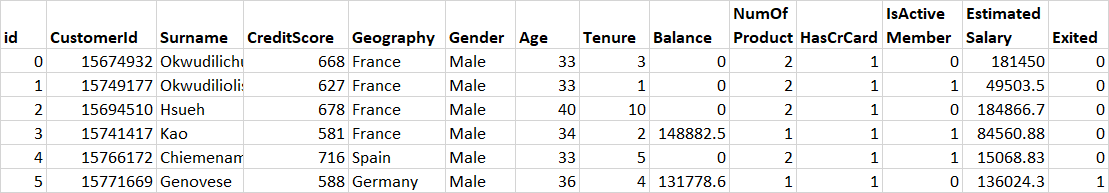

---
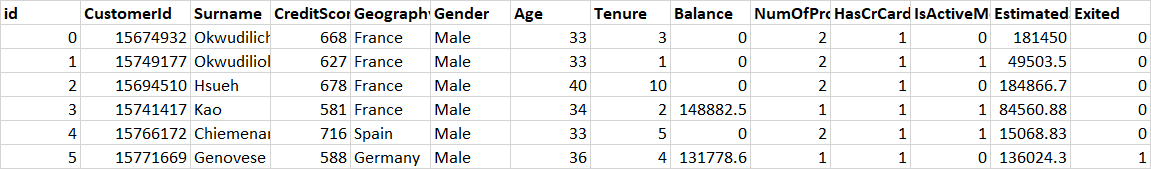

## Расшифровка столбцов

- id: порядковый номер записи(строки) в датасете. Никак не влияет на логику. Исключаю из обработки
- CustomerId: айди пользователя в системе банка. Тоже не должно никак влиять на итог. Исключаю из обработки
- Surname: фамилия пользователя. Пока не понятно надо ли это. Попробую включить в обработку
- CreditScore: кредитный рейтинг. Включаю в обработку
- Geography: видимо гражданство или место проживания пользователя. (К сожалению нет инф где находится сам банк или его филиалы). Включаю в обработку
- Gender: пол пользователя. Включаю в обработку
- Age: возраст, в годах. Включаю в обработку
- Tenure: сколько **лет** пользователь уже клиент банка. Включаю в обработку
- Balance: тут не понятно какой именно баланс (средний, текущий ..) на счетах банка. Включаю в обработку
- NumOfProducts: видимо количество продуктов банка в использовании. Включаю в обработку
- HasCrCard: видимо имеет действующую кредитную карту (посмотреть связи с балансом и с кредитным рейтингом). Включаю в обработку
- IsActiveMember: является активным пользователем (не очень понятен контекст значения). Включаю в обработку
- EstimatedSalary: расчетная зарплата(доход), видимо за год. Включаю в обработку
- Exited: пользователь перестал быть клиентом банка. Целевой столбец для предсказания. Включаю в обработку

---

#### Имена датасетов ниже:


df_raw = pd.read_csv('datasets/bank_churn_raw.csv')


df_filtered
датасет после drop ['id', 'CustomerId', 'Surname']
фичи Geography, Gender -


X_catboost
датасет после drop ['id', 'CustomerId', 'Surname']
И Geography, Gender - разложены как ohe


df_expanded = X_catboost.copy()
добавлены фичи:
Balance_Salary_Ratio, Products_Per_Year, Financial_Activity, Age_Tenure_Interaction


Y = X_catboost["Exited"] или из df_filtered или из df_expanded - для проверки

X_raw = X_catboost.drop(["Exited"], axis=1) или из df_filtered или из df_expanded - для обучения

## Раздел 1. Исследование исходных данных

---

In [1]:
# All imports

import pandas as pd
import numpy as np
import time
from datetime import datetime, timezone, timedelta

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split, cross_validate
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier

from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import seaborn as sns


model_version = '0.5.4'
# 0.5.2 expanded with extra combined features
# 0.5.0 fully refactored


In [2]:
# Scalers dict to try different scalers

baseline_scaler = StandardScaler()

# removed this from loops to save time.

# scalers = {
#     'standardScaler': StandardScaler(),
#     'minmaxScaler': MinMaxScaler(),
#     'robustScaler': RobustScaler()
# }

# Function to log results into csv file
def save_results_to_csv(model_name, scaler_name, accuracy, recall, precision, f1, train_time, filename='ml_logs.csv'):

    # set time offset (UTC+3)
    TZ_OFFSET = timedelta(hours=3)
    tz = timezone(TZ_OFFSET)
    current_time = datetime.now(tz).isoformat(timespec='seconds')
    print(f'current time is: {current_time}')

    # csv columns result dict
    result = {
        'date_time': current_time,
        'model_name': model_name,
        'scaler': scaler_name,
        'accuracy': round(accuracy, 4),
        'recall': round(recall, 4),
        'precision': round(precision, 4),
        'f1_score': round(f1, 4),
        'train_time_seconds': round(train_time, 4),
        'model_version': model_version
    }

    # result dict to dataframe
    df_result = pd.DataFrame([result])

    # write logs to CSV
    try:
        existing_csv = pd.read_csv(filename)
        df_result.to_csv(filename, mode='a', header=False, index=False)
        print(f'result logged to {filename}')
    except FileNotFoundError:
        df_result.to_csv(filename, mode='w', header=True, index=False)
        print(f'file created: {filename}')

### Раздел 1.1 Загрузка исходных данных

In [3]:
df_raw = pd.read_csv('datasets/bank_churn_raw.csv')


In [4]:
print(f'total rows, columns: {df_raw.shape}')
df_raw.head()

total rows, columns: (165034, 14)


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1,0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1,1,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1,0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1,1,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1,1,15068.83,0


---

### Раздел 1.2 Проверка пропусков и дубликатов

In [5]:
# check gaps in the columns
df_raw.isnull().sum()

null_amount = df_raw.isnull().sum()

if null_amount.sum() == 0:
    print('data gaps in cells - NO')
else:
    columns_with_null = null_amount[null_amount > 0].to_dict()
    print(columns_with_null)

data gaps in cells - NO


In [6]:
# duplicate check
duplicate_count = df_raw.duplicated().sum()
print(f"entire row duplicates: {duplicate_count}")

if duplicate_count > 0:
    duplicate_rows = df_raw[df_raw.duplicated()]
    print(duplicate_rows)
    print('-'*15)

# check duplicates in id and CustomerId
for column in ['id']:
    duplicates = df_raw.duplicated(subset=[column], keep=False)
    duplicate_count = duplicates.sum()

    if duplicate_count > 0:
        dup_indices = df_raw[duplicates].index.tolist()
        print(f'Column "{column}" contains: "{duplicate_count}" duplicates')
        print(f'duplicated row index: {dup_indices}')

        dup_values = df_raw[duplicates][column].tolist()
        print(f'duplicated values: {dup_values}\n')
    else:
        print(f'Duplicates in the column: "{column}" - NO\n')



entire row duplicates: 0
Duplicates in the column: "id" - NO



In [7]:
# separated code block because found many duplicates in the column
for column in ['CustomerId']:
    duplicates = df_raw.duplicated(subset=[column], keep=False)
    duplicate_count = duplicates.sum()

    if duplicate_count > 0:
        dup_indices = df_raw[duplicates].index.tolist()
        print(f'Column "{column}" contains: "{duplicate_count}" duplicates')
        print(f'duplicate indexes: {dup_indices}')

        dup_values = df_raw[duplicates][column].tolist()
        print(f' duplicate values: {dup_values}\n')
    else:
        print(f' Column "{column}" duplicates - NO\n')

Column "CustomerId" contains: "155733" duplicates
duplicate indexes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 153, 154, 156, 157, 158, 159, 160, 161, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 21

---
Столбец CustomerId ^ содержит повторы айдишек клиентов, хотя значения в других столбцах отличаются. Чего быть в принципе не должно. Убираю этот столбец из обработки т.к. айди пользователя не влияет на логику решений.

---

In [8]:
# new filtered dataframe
# Столбец с фамилией пока тоже убираю, т.к. не должно влиять и не понятно чего с ним делать

COLUMNS_DROP = ['id', 'CustomerId', 'Surname']

# df_filtered - dataframe to work with
df_filtered = df_raw.drop(columns=COLUMNS_DROP).copy()
print(f'total rows, columns: {df_filtered.shape}')

df_filtered.head()

total rows, columns: (165034, 11)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,668,France,Male,33.0,3,0.00,2,1,0,181449.97,0
1,627,France,Male,33.0,1,0.00,2,1,1,49503.50,0
2,678,France,Male,40.0,10,0.00,2,1,0,184866.69,0
3,581,France,Male,34.0,2,148882.54,1,1,1,84560.88,0
4,716,Spain,Male,33.0,5,0.00,2,1,1,15068.83,0


In [259]:
# df_filtered.describe(include='all')


---
---

## Раздел 2. Подготовка данных
Столбцы 'Geography', 'Gender' надо преобразовать в цифровой вид.
Потом нормализовать все столбцы в один масштаб данных

### Раздел 2.1 Текстовые значение в цифровые

In [9]:
# Declared function to check column details (value, amount in the column, percentage)

def column_stats_table(df_check, column_check):
    counts = df_check[column_check].value_counts()
    percentages = df_check[column_check].value_counts(normalize=True) * 100

    column_stats = pd.DataFrame({
        'value': counts.index,
        'count': counts.values,
        'percentage': percentages.values
    })

    return column_stats


---

In [10]:
# Check column details

column_stats_table(df_filtered,'Geography')

,value,count,percentage
0,France,94215,57.088236
1,Spain,36213,21.942751
2,Germany,34606,20.969012


In [11]:
column_stats_table(df_filtered,'Gender')

,value,count,percentage
0,Male,93150,56.442915
1,Female,71884,43.557085


In [178]:
# Столбец Gender в формат категорий

# df_filtered['Gender'] = pd.Categorical(df_filtered['Gender'])
# print(f'тип данных в столбце: {df_filtered['Gender'].dtype}')
#
# gender_coded_values = sorted(df_filtered['Gender'].unique())
# gender_dict = {value: idx for idx, value in enumerate(gender_coded_values)}
# print(gender_dict)


df_filtered.corr() не работает с категоризованными столбцами через пандас.  надо все-таки явно заменить значения на цифры

LabelEncoder() из sklearn.preprocessing работает норм

In [12]:
# Encode Geography values into numeric type

if 'Geo_encoded' in df_filtered.columns:
    df_filtered.drop(columns=['Geo_encoded'], inplace=True)

geo_encoded = LabelEncoder()
idx = df_filtered.columns.get_loc('Geography')
df_filtered.insert(idx + 1, 'Geo_encoded', geo_encoded.fit_transform(df_filtered['Geography']))

df_filtered.head()

,CreditScore,Geography,Geo_encoded,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,668,France,0,Male,33.0,3,0.00,2,1,0,181449.97,0
1,627,France,0,Male,33.0,1,0.00,2,1,1,49503.50,0
2,678,France,0,Male,40.0,10,0.00,2,1,0,184866.69,0
3,581,France,0,Male,34.0,2,148882.54,1,1,1,84560.88,0
4,716,Spain,2,Male,33.0,5,0.00,2,1,1,15068.83,0


In [13]:
# Encode Gender values into numeric

if 'Gender_encoded' in df_filtered.columns:
    df_filtered.drop(columns=['Gender_encoded'], inplace=True)

gender_encoded = LabelEncoder()

idx = df_filtered.columns.get_loc('Gender')
df_filtered.insert(idx + 1, 'Gender_encoded', gender_encoded.fit_transform(df_filtered['Gender']))

df_filtered.head()

,CreditScore,Geography,Geo_encoded,Gender,Gender_encoded,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,668,France,0,Male,1,33.0,3,0.00,2,1,0,181449.97,0
1,627,France,0,Male,1,33.0,1,0.00,2,1,1,49503.50,0
2,678,France,0,Male,1,40.0,10,0.00,2,1,0,184866.69,0
3,581,France,0,Male,1,34.0,2,148882.54,1,1,1,84560.88,0
4,716,Spain,2,Male,1,33.0,5,0.00,2,1,1,15068.83,0


In [14]:
# Drop original columns with string types
df_filtered.drop(columns = ['Geography', 'Gender'], inplace=True)

# Correlation check
df_filtered.corr()

,CreditScore,Geo_encoded,Gender_encoded,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
CreditScore,1.000000,0.005379,0.002310,-0.008918,0.000942,0.006973,0.011361,-0.002828,0.014790,-0.001820,-0.027383
Geo_encoded,0.005379,1.000000,-0.012092,0.034110,0.000276,0.134642,-0.025123,-0.016715,-0.003493,-0.004102,0.053343
Gender_encoded,0.002310,-0.012092,1.000000,-0.063139,0.008767,-0.014699,0.026098,0.006418,0.033722,-0.007778,-0.146442
Age,-0.008918,0.034110,-0.063139,1.000000,-0.010830,0.064318,-0.102195,-0.012111,0.003320,-0.005399,0.340768
Tenure,0.000942,0.000276,0.008767,-0.010830,1.000000,-0.009481,0.007335,0.005327,-0.005532,0.000971,-0.019565
Balance,0.006973,0.134642,-0.014699,0.064318,-0.009481,1.000000,-0.361033,-0.018584,-0.015073,0.008586,0.129743
NumOfProducts,0.011361,-0.025123,0.026098,-0.102195,0.007335,-0.361033,1.000000,0.005482,0.039736,-0.004285,-0.214554
HasCrCard,-0.002828,-0.016715,0.006418,-0.012111,0.005327,-0.018584,0.005482,1.000000,-0.021034,0.004438,-0.022141
IsActiveMember,0.014790,-0.003493,0.033722,0.003320,-0.005532,-0.015073,0.039736,-0.021034,1.000000,-0.008080,-0.210237
EstimatedSalary,-0.001820,-0.004102,-0.007778,-0.005399,0.000971,0.008586,-0.004285,0.004438,-0.008080,1.000000,0.018827


---
## Раздел 2. Нормализация данных по столбцам

In [182]:
# нормализовать столбцы с числовыми значениями, кроме столбцов с [0,1]
# сейчас метод нормализации minmax из sklearn
# надо будет перебрать несколько способов

# def normalize_columns(df_to_normal):
#     cols_to_norm = [col for col in df_to_normal.select_dtypes(include=['int64', 'float64']).columns
#                     if not set(df_to_normal[col].unique()).issubset({0, 1})]
#     binary_cols = [col for col in df_to_normal.select_dtypes(include=['int64', 'float64']).columns
#                    if set(df_to_normal[col].unique()).issubset({0, 1})]
#
#     df_norm = df_to_normal[cols_to_norm].copy()
#     if cols_to_norm:
#         df_norm[cols_to_norm] = MinMaxScaler().fit_transform(df_norm[cols_to_norm])
#     if binary_cols:
#         df_norm = pd.concat([df_norm, df_to_normal[binary_cols]], axis=1)
#
#     print(f'normalized columns: {cols_to_norm} \nbinary columns as is: {binary_cols}')
#     print('-'*15)
#     return df_norm
#
#
# df_normalized = normalize_columns(df_filtered)
# print('\n', df_normalized.head())

---
## Раздел 3. Подготовка к обучению

проверим соотношение значений в целевом столбце

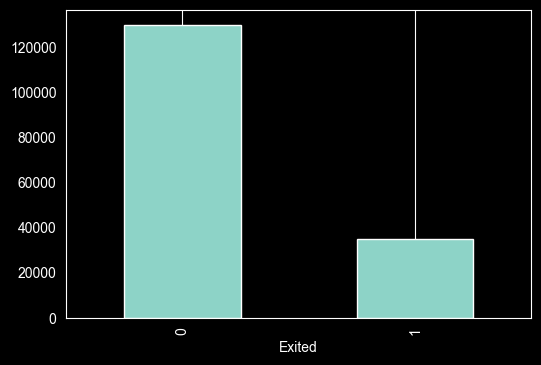

In [15]:
df_filtered['Exited'].value_counts().plot.bar(figsize=(6, 4))
plt.grid(axis='y')

In [16]:
column_stats_table(df_filtered, 'Exited')

,value,count,percentage
0,0,130113,78.840118
1,1,34921,21.159882



следующий шаг: проверить распределения значений по всем колонкам в датасете

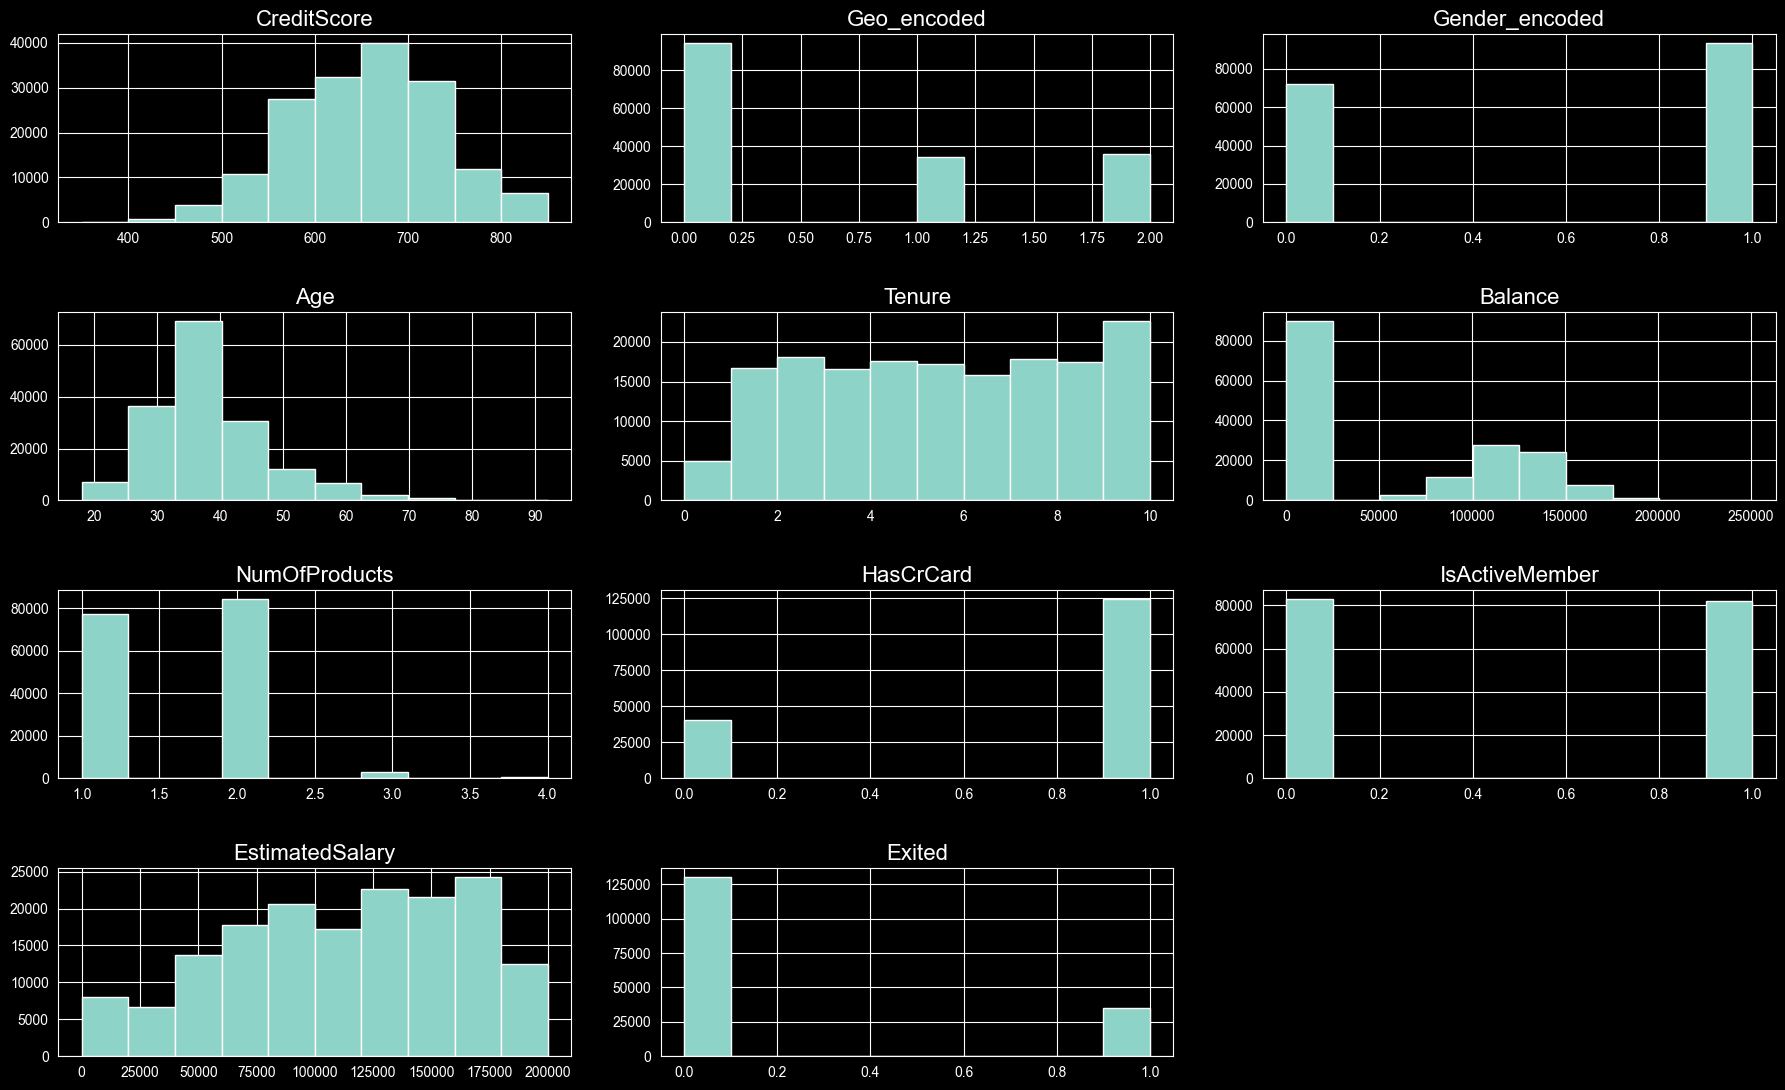

In [17]:

plt.rc('axes', titlesize=16)
df_filtered.hist(figsize=(18, 11), xlabelsize=10, ylabelsize=10)
plt.tight_layout(h_pad=3.0, w_pad=2.0)
# тут надо бы еще добавить абсолютные мин/макс значения (до нормализации)

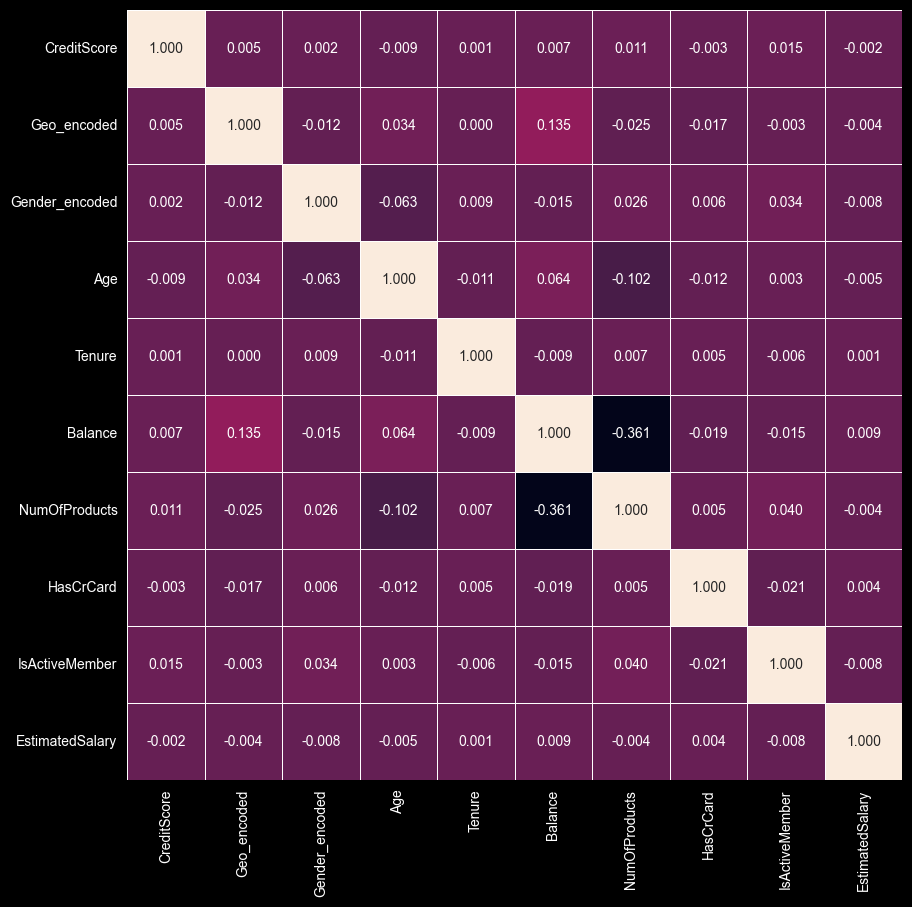

In [18]:
# Correlations without target column, as heatmap render

plt.figure(figsize=(10, 10))
sns.heatmap(df_filtered.drop(['Exited'], axis=1).corr(), annot=True, cbar=False, linewidths=.5, fmt= '.3f')
plt.show()

максимальное значение - |0.361| вроде можем пренебречь и идти дальше

In [19]:
# Separate target and other features
Y = df_filtered['Exited']
X_raw = df_filtered.drop(['Exited'],axis=1)


print(f'Features shape: {X_raw.shape}')
print(f'Target shape: {Y.shape}')




Features shape: (165034, 10)
Target shape: (165034,)


In [20]:
# Extra feature engineering (for catboost initially)
# Separate data frame copy to experiment with features.
# Set this block here to try all models with ohe features

COLUMNS_DROP = ['id', 'CustomerId', 'Surname']
X_catboost = df_raw.drop(columns=COLUMNS_DROP).copy()

# Geography replacement 1 to 3 cols

#column_stats_table(X_catboost,'Geography')

geo_cols = []
geo_cols = X_catboost.columns[X_catboost.columns.str.startswith('Geo_')]
if geo_cols.size > 0:
    X_catboost.drop(columns=geo_cols, inplace=True)

# join ohe columns, drop the original column after that
idx = X_catboost.columns.get_loc('Geography')
geo_ohe = pd.get_dummies(X_catboost['Geography'], prefix='Geo', dtype=int)

for i, col_name in enumerate(geo_ohe.columns):
    X_catboost.insert(idx +1 +i, col_name, geo_ohe[col_name])


# Gender replacement 1 to 2 cols
column_stats_table(X_catboost,'Gender')

geo_cols = []
geo_cols = X_catboost.columns[X_catboost.columns.str.startswith('Gender_')]
if geo_cols.size > 0:
    X_catboost.drop(columns=geo_cols, inplace=True)

# join ohe columns, drop the original column after that
idx = X_catboost.columns.get_loc('Gender')
geo_ohe = pd.get_dummies(X_catboost['Gender'], prefix='Gender', dtype=int)

for i, col_name in enumerate(geo_ohe.columns):
    X_catboost.insert(idx +1 +i, col_name, geo_ohe[col_name])

X_catboost = X_catboost.drop(['Geography','Gender'], axis=1)



In [21]:
# normalization function setup
# this function TO BE DEPRECATED after fixing logic via pipeline instead

def normalize_columns(dataset_input, scaler_name):
    # scalers being taken from scaler dict (StandardScaler, MinMaxScaler, RobustScaler)

    # columns to normalize - numeric, not binary
    cols_to_norm = [col for col in dataset_input.select_dtypes(include=['int64', 'float64']).columns
                    if not set(dataset_input[col].unique()).issubset({0, 1})]

    # binary columns
    binary_cols = [col for col in dataset_input.select_dtypes(include=['int64', 'float64']).columns
                   if set(dataset_input[col].unique()).issubset({0, 1})]

    # normalize numeric columns
    dataset_norm = dataset_input[cols_to_norm].copy()

    if cols_to_norm:
        dataset_norm[cols_to_norm] = scaler_name.fit_transform(dataset_norm[cols_to_norm])

    if binary_cols:
        dataset_norm = pd.concat([dataset_norm, dataset_input[binary_cols]], axis=1)

    print('-'*15)
    print(f'Scaler used: {scaler_name.__class__.__name__}')
    print(f'Normalized columns: {cols_to_norm}')
    print(f'Binary columns as is: {binary_cols}')
    print('-'*15)

    return dataset_norm





In [22]:
# make 2 datasets as function - Y with target and X_raw with feature columns

def separate_feature_target_columns ():
    Y = df_filtered['Exited']
    X_raw = df_filtered.drop(['Exited'],axis=1)
    print(f'Feature columns: {X_raw.shape}')
    print(f'Target column: {Y.shape}')
    return X_raw, Y



In [23]:
# training logic automation

# Cross validation setup
cv = StratifiedKFold(n_splits=7, shuffle=True, random_state=555)

def train_model_with_scalers(
    model,
    model_name_for_log,
    X_scaled,
    Y_df,
    cv_strategy,
    scaler_name=baseline_scaler,
):

    results_list = []

    print(f'\n{"-"*15}')
    print(f"Training {model_name_for_log} with {scaler_name}")
    print(f'\n{"-"*15}')

    # Pipeline approach
    baseline_scaler = StandardScaler()
    pipeline = Pipeline([("scaler", baseline_scaler), ("classifier", model)])

    # Track train time
    start_time = time.time()

    # Optimized: Performs cross-validation for all metrics in in one go (each fold run)
    scoring_metrics = ["accuracy", "recall", "precision", "f1"]
    cv_results = cross_validate(
        pipeline, X_scaled, Y_df, cv=cv_strategy, scoring=scoring_metrics
    )

    train_time = time.time() - start_time

    # mean metric values extracted cleanly
    mean_accuracy = cv_results["test_accuracy"].mean()
    mean_recall = cv_results["test_recall"].mean()
    mean_precision = cv_results["test_precision"].mean()
    mean_f1 = cv_results["test_f1"].mean()

    # Display results
    print(f"Train time: {train_time:.4f} seconds")
    print(
        f'Accuracy: {mean_accuracy:.4f} (+/- {cv_results["test_accuracy"].std() * 2:.4f})'
    )
    print(f"Recall: {mean_recall:.4f}")
    print(f"Precision: {mean_precision:.4f}")
    print(f"F1-Score: {mean_f1:.4f}")

    # Save to CSV
    save_results_to_csv(
        model_name=f"{model_name_for_log}",
        scaler_name=scaler_name,
        accuracy=mean_accuracy,
        recall=mean_recall,
        precision=mean_precision,
        f1=mean_f1,
        train_time=train_time,
    )

    results_list.append(
        {
            "scaler": scaler_name,
            "accuracy": mean_accuracy,
            "recall": mean_recall,
            "precision": mean_precision,
            "f1": mean_f1,
            "train_time": train_time,
        }
    )

    return results_list


In [299]:
# ============================================
# BLOCK 20: LOGISTIC REGRESSION
# ============================================

# separate target and other features
Y = X_catboost["Exited"]
X_raw = X_catboost.drop(["Exited"], axis=1)

print("\n" + "=" * 15)
print("MODEL 1: LOGISTIC REGRESSION WITH ALL SCALERS")
print("-" * 15)

# Find best parameters
print("Grid search for Logistic Regression model...")
best_logreg_f1 = 0
best_logreg_params = None

C_values = [0.0001]
l1_ratio_values = [0.66]
max_iterations = 500

for C in C_values:
    for l1_ratio in l1_ratio_values:

        # Used auto elastic for l1_ratio. instead of penalty='elasticnet'. due to python lib warnings
        logreg_temp = LogisticRegression(
            #penalty="elasticnet",
            C=C,
            l1_ratio=l1_ratio,
            solver="saga",
            max_iter=max_iterations,
            random_state=555,
            class_weight="balanced",  # for imbalanced data (my target is 79/21)
        )

        if l1_ratio == 0:
            reg_type = "L2"
        elif l1_ratio == 1:
            reg_type = "L1"
        else:
            reg_type = f"ElasticNet({l1_ratio})"

        # Applied pipeline function for grid search
        baseline_scaler = StandardScaler()
        search_pipeline = Pipeline(
            [("scaler", baseline_scaler), ("classifier", logreg_temp)]
        )

        # F1 score metric
        f1_scores = cross_val_score(
            search_pipeline, X_raw, Y, cv=cv, scoring="f1"
        )
        mean_f1 = f1_scores.mean()
        print(f"C={C}, {reg_type}: F1={mean_f1:.4f}")

        if mean_f1 > best_logreg_f1:
            best_logreg_f1 = mean_f1
            best_logreg_params = {
                "C": C,
                "l1_ratio": l1_ratio,
                "reg_type": reg_type,
            }

print(
    f'\nBest parameters: C={best_logreg_params["C"]}, {best_logreg_params["reg_type"]}'
)
print(f"Best F1={best_logreg_f1:.4f}")

# check best model
logreg_best = LogisticRegression(
    # penalty="elasticnet",  # gpt suggested adding this to process l1 ratio properly.but this is already automated in newer lib versions
    C=best_logreg_params["C"],
    l1_ratio=best_logreg_params["l1_ratio"],
    solver="saga",
    max_iter=max_iterations,
    random_state=555,
    class_weight="balanced",  # added to rebalance and increase recall
)

# Train best found model
logreg_results = train_model_with_scalers(
    model=logreg_best,
    model_name_for_log=f'LogisticRegression_C{best_logreg_params["C"]}_{best_logreg_params["reg_type"]}_balanced',
    X_scaled=X_raw,  # To scale it fold-by-fold
    Y_df=Y,
    cv_strategy=cv,
)



MODEL 1: LOGISTIC REGRESSION WITH ALL SCALERS
---------------
Grid search for Logistic Regression model...
C=0.0001, ElasticNet(0.66): F1=0.5638

Best parameters: C=0.0001, ElasticNet(0.66)
Best F1=0.5638

---------------
Training LogisticRegression_C0.0001_ElasticNet(0.66)_balanced with StandardScaler()

---------------
Train time: 9.3950 seconds
Accuracy: 0.7620 (+/- 0.0050)
Recall: 0.7268
Precision: 0.4605
F1-Score: 0.5638
current time is: 2026-06-11T13:15:17+03:00
result logged to ml_logs.csv


In [301]:

# ============================================
# BLOCK 21: DECISION TREE
# ============================================

# separate target and other features
Y = X_catboost["Exited"]
X_raw = X_catboost.drop(["Exited"], axis=1)

print("\n" + "=" * 15)
print("MODEL 2: DECISION TREE")
print("-" * 15)

# Find best max_depth
print("best max_depth for Decision Tree")
best_depth = None
best_f1 = 0

# Depth options
for max_depth in [6, 7, 8, 9]:

    # Added class_weight='balanced' to handle target imbalance
    dt_temp = DecisionTreeClassifier(
        max_depth=max_depth,
        random_state=555,
        class_weight="balanced",  # Added to align F1 metric
    )

    # Applied pipeline function for grid search
    baseline_scaler = StandardScaler()
    search_pipeline = Pipeline(
        [("scaler", baseline_scaler), ("classifier", dt_temp)]
    )

    # F1 score as metric
    f1_scores = cross_val_score(search_pipeline, X_raw, Y, cv=cv, scoring="f1")
    mean_f1 = f1_scores.mean()
    print(f"depth={max_depth}: F1={mean_f1:.4f}")

    if mean_f1 > best_f1:
        best_f1 = mean_f1
        best_depth = max_depth

print(f"\nBest max_depth: {best_depth} (F1={best_f1:.4f})")

# Use best model
dt_best = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=555,
    class_weight="balanced",
)

# Train Decision Tree with best depth
dt_results = train_model_with_scalers(
    model=dt_best,
    model_name_for_log=f"DecisionTree_depth{best_depth}_balanced",
    X_scaled=X_raw,
    Y_df=Y,
    cv_strategy=cv,
)




MODEL 2: DECISION TREE WITH ALL SCALERS
---------------
best max_depth for Decision Tree model
depth=6: F1=0.6342
depth=8: F1=0.6383
depth=9: F1=0.6334
depth=10: F1=0.6297
depth=None: F1=0.5242

Best max_depth: 8 (F1=0.6383)

---------------
Training DecisionTree_depth8_balanced with StandardScaler()

---------------
Train time: 3.6620 seconds
Accuracy: 0.8137 (+/- 0.0075)
Recall: 0.7771
Precision: 0.5417
F1-Score: 0.6383
current time is: 2026-06-11T13:22:47+03:00
result logged to ml_logs.csv


In [306]:
# ============================================
# BLOCK 22: TRAIN LIGHTGBM
# ============================================

print("\n" + "=" * 15)
print("MODEL 3: LIGHTGBM WITH ALL SCALERS")
print("-" * 15)

# Find best parameters for LightGBM
print("Grid search for LightGBM model...")
best_lgb_f1 = 0
best_lgb_params = None

# Grid parameters declared as variables
learning_rates = [0.09, 0.1, 0.12]
max_depth_options = [5, 7, 10]
num_leaves_options = [7, 15, 25]
n_estimators_options = [90, 100, 150]
imbalance_weight_options = [2.0, 2.5 ,3.0]

# Params declared as variables
fixed_subsample = 0.8
fixed_colsample = 0.8
fixed_alpha = 0.1
fixed_lambda = 0.1

# Grid search
for lr in learning_rates:
    for num_leaves in num_leaves_options:
        for n_estimators in n_estimators_options:
            for max_depth in max_depth_options:
                for scale_weight in imbalance_weight_options:  # added to try different weight options
                    # Skip invalid combinations (num_leaves should be <= 2^max_depth)
                    if max_depth is not None and num_leaves > (2**max_depth):
                        continue

                    # used params
                    lgb_temp = lgb.LGBMClassifier(
                        learning_rate=lr,
                        num_leaves=num_leaves,
                        n_estimators=n_estimators,
                        max_depth=max_depth,
                        subsample=fixed_subsample,
                        colsample_bytree=fixed_colsample,
                        reg_alpha=fixed_alpha,
                        reg_lambda=fixed_lambda,
                        random_state=555,
                        verbose=-1,
                        scale_pos_weight=scale_weight,  # check with different weights
                    )

                    # Applied pipeline function for grid search
                    baseline_scaler = StandardScaler().set_output(transform="pandas")
                    # added .set_output(transform="pandas") to transform headless df into named df
                    search_pipeline = Pipeline(
                        [("scaler", baseline_scaler), ("classifier", lgb_temp)]
                    )

                    # F1 metric
                    f1_scores = cross_val_score(
                        search_pipeline, X_raw, Y, cv=cv, scoring="f1"
                    )
                    mean_f1 = f1_scores.mean()
                    print(
                        f"lr={lr}, leaves={num_leaves}, estimators={n_estimators}, depth={max_depth}, weight={scale_weight}: F1={mean_f1:.4f}"
                    )

                    if mean_f1 > best_lgb_f1:
                        best_lgb_f1 = mean_f1
                        best_lgb_params = {
                            "learning_rate": lr,
                            "num_leaves": num_leaves,
                            "n_estimators": n_estimators,
                            "max_depth": max_depth,
                            "scale_pos_weight": scale_weight,
                        }

print(
    f'\nBest parameters: lr={best_lgb_params["learning_rate"]}, leaves={best_lgb_params["num_leaves"]}, '
    f'estimators={best_lgb_params["n_estimators"]}, depth={best_lgb_params["max_depth"]}, '
    f'scale_pos_weight={best_lgb_params["scale_pos_weight"]}'
)
print(f"Best F1={best_lgb_f1:.4f}")

# Check best model
lgb_best = lgb.LGBMClassifier(
    learning_rate=best_lgb_params["learning_rate"],
    num_leaves=best_lgb_params["num_leaves"],
    n_estimators=best_lgb_params["n_estimators"],
    max_depth=best_lgb_params["max_depth"],
    subsample=fixed_subsample,
    colsample_bytree=fixed_colsample,
    reg_alpha=fixed_alpha,
    reg_lambda=fixed_lambda,
    random_state=555,
    verbose=-1,
    scale_pos_weight=best_lgb_params["scale_pos_weight"],
)

# Train best model
lgb_results = train_model_with_scalers(
    model=lgb_best,
    model_name_for_log=f'LightGBM_lr{best_lgb_params["learning_rate"]}_leaves{best_lgb_params["num_leaves"]}_estimators{best_lgb_params["n_estimators"]}_maxdepth{best_lgb_params["max_depth"]}_scale_pos_weight{best_lgb_params["scale_pos_weight"]}',
    X_scaled=X_raw,
    Y_df=Y,
    cv_strategy=cv,
)



MODEL 3: LIGHTGBM WITH ALL SCALERS
---------------
Grid search for LightGBM model...
lr=0.09, leaves=7, estimators=90, depth=5, weight=2.0: F1=0.6628
lr=0.09, leaves=7, estimators=90, depth=5, weight=2.5: F1=0.6604
lr=0.09, leaves=7, estimators=90, depth=5, weight=3.0: F1=0.6508
lr=0.09, leaves=7, estimators=90, depth=7, weight=2.0: F1=0.6628
lr=0.09, leaves=7, estimators=90, depth=7, weight=2.5: F1=0.6601
lr=0.09, leaves=7, estimators=90, depth=7, weight=3.0: F1=0.6509
lr=0.09, leaves=7, estimators=90, depth=10, weight=2.0: F1=0.6628
lr=0.09, leaves=7, estimators=90, depth=10, weight=2.5: F1=0.6601
lr=0.09, leaves=7, estimators=90, depth=10, weight=3.0: F1=0.6509
lr=0.09, leaves=7, estimators=100, depth=5, weight=2.0: F1=0.6633
lr=0.09, leaves=7, estimators=100, depth=5, weight=2.5: F1=0.6603
lr=0.09, leaves=7, estimators=100, depth=5, weight=3.0: F1=0.6513
lr=0.09, leaves=7, estimators=100, depth=7, weight=2.0: F1=0.6631
lr=0.09, leaves=7, estimators=100, depth=7, weight=2.5: F1=0.6

C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWa

Train time: 4.6890 seconds
Accuracy: 0.8537 (+/- 0.0061)
Recall: 0.6904
Precision: 0.6439
F1-Score: 0.6663
current time is: 2026-06-11T14:30:00+03:00
result logged to ml_logs.csv


C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [313]:
# Expanded df copy to combine features
df_expanded = X_catboost.copy()

# 1. Balance-to-Salary Ratio (Identifies high-earners with empty accounts)
df_expanded['Balance_Salary_Ratio'] = df_expanded['Balance'] / (df_expanded['EstimatedSalary'] + 1)

# 2. Product Utilization Velocity (How fast they adopt products relative to time spent)
df_expanded['Products_Per_Year'] = df_expanded['NumOfProducts'] / (df_expanded['Tenure'] + 1)

# 3. Financial Activity Index (Combines credit card ownership and active membership status)
df_expanded['Financial_Activity'] = df_expanded['HasCrCard'] + df_expanded['IsActiveMember']

# 4. Age and Tenure Interaction (Differentiates young new accounts from older loyal accounts)
df_expanded['Age_Tenure_Interaction'] = df_expanded['Age'] * df_expanded['Tenure']

print(f"Features successfully expanded from {X_catboost.shape[1]} to {df_expanded.shape[1]} columns!")
df_expanded.head()

Features successfully expanded from 14 to 18 columns!


,CreditScore,Geo_France,Geo_Germany,Geo_Spain,Gender_Female,Gender_Male,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Balance_Salary_Ratio,Products_Per_Year,Financial_Activity,Age_Tenure_Interaction
0,668,1,0,0,0,1,33.0,3,0.00,2,1,0,181449.97,0,0.000000,0.500000,1,99.0
1,627,1,0,0,0,1,33.0,1,0.00,2,1,1,49503.50,0,0.000000,1.000000,2,33.0
2,678,1,0,0,0,1,40.0,10,0.00,2,1,0,184866.69,0,0.000000,0.181818,1,400.0
3,581,1,0,0,0,1,34.0,2,148882.54,1,1,1,84560.88,0,1.760634,0.333333,2,68.0
4,716,0,0,1,0,1,33.0,5,0.00,2,1,1,15068.83,0,0.000000,0.333333,2,165.0


In [316]:

# ============================================
# BLOCK 23: TRAIN CATBOOST
# ============================================

print('\n' + "="*15)
print('MODEL 3: CATBOOST')
print('-'*15)

Y = df_expanded['Exited']
X_raw = df_expanded.drop(['Exited'],axis=1)

# Grid searc
print("Grid search for CatBoost model..")
best_cat_f1 = 0
best_cat_params = None

# Grid parameters declared as variables
learning_rates = [0.06, 0.07] # [0.07,0.08, 0.09]
depths = [8, 9, 10] # [9, 10]
iterations_options = [300, 400] # [300, 800]
l2_leaf_reg_options = [4, 7] #[4, 7]
imbalance_weight_options = [1.5 , 2.0] #[2.0, 2.5 ,3.0]

# best on catboost df: lr=0.07, depth=9, iterations=300, l2_reg=4, scale_pos_weight=2.0 Best F1=0.6644
# best on expanded df: lr=0.06, depth=8, iterations=400, l2_reg=4, scale_pos_weight=2.0 Best F1=0.6647

# param config
fixed_bootstrap = "Bernoulli"
fixed_subsample = 0.8

# Grid search
for lr in learning_rates:
    for depth in depths:
        for iterations in iterations_options:
            for l2_reg in l2_leaf_reg_options:
                for scale_weight in imbalance_weight_options:
                    cat_temp = CatBoostClassifier(
                        learning_rate=lr,
                        depth=depth,
                        iterations=iterations,
                        l2_leaf_reg=l2_reg,
                        loss_function="Logloss",
                        eval_metric="F1:use_weights=false",  # check unweighted F1 in validation
                        random_seed=555,
                        verbose=False,
                        scale_pos_weight=scale_weight,
                        bootstrap_type=fixed_bootstrap,
                        subsample=fixed_subsample,
                    )

                    # Applied pipeline function for grid search
                    baseline_scaler = StandardScaler().set_output(
                        transform="pandas"
                    )
                    search_pipeline = Pipeline(
                        [("scaler", baseline_scaler), ("classifier", cat_temp)]
                    )

                    # F1 metric
                    f1_scores = cross_val_score(
                        search_pipeline, X_raw, Y, cv=cv, scoring="f1"
                    )
                    mean_f1 = f1_scores.mean()
                    print(
                        f"lr={lr}, depth={depth}, iterations={iterations}, l2_reg={l2_reg}, weight={scale_weight}: F1={mean_f1:.4f}"
                    )

                    if mean_f1 > best_cat_f1:
                        best_cat_f1 = mean_f1
                        best_cat_params = {
                            "learning_rate": lr,
                            "depth": depth,
                            "iterations": iterations,
                            "l2_leaf_reg": l2_reg,
                            "scale_pos_weight": scale_weight,
                        }

print(
    f'\nBest parameters: lr={best_cat_params["learning_rate"]}, depth={best_cat_params["depth"]}, '
    f'iterations={best_cat_params["iterations"]}, l2_reg={best_cat_params["l2_leaf_reg"]}, '
    f'scale_pos_weight={best_cat_params["scale_pos_weight"]}'
)
print(f"Best F1={best_cat_f1:.4f}")

# Best model
cat_best = CatBoostClassifier(
    learning_rate=best_cat_params["learning_rate"],
    depth=best_cat_params["depth"],
    iterations=best_cat_params["iterations"],
    l2_leaf_reg=best_cat_params["l2_leaf_reg"],
    loss_function="Logloss",
    eval_metric="F1:use_weights=false",
    random_seed=555,
    verbose=False,
    scale_pos_weight=best_cat_params["scale_pos_weight"],
    bootstrap_type=fixed_bootstrap,
    subsample=fixed_subsample,
)

# Train best model
cat_results = train_model_with_scalers(
    model=cat_best,
    model_name_for_log=f'CatBoost_lr{best_cat_params["learning_rate"]}_depth{best_cat_params["depth"]}_iter{best_cat_params["iterations"]}_l2_leaf_reg_options{best_cat_params["l2_leaf_reg"]}_scale_pos_weight{best_cat_params["scale_pos_weight"]}',
    X_scaled=X_raw,
    Y_df=Y,
    cv_strategy=cv,
)



MODEL 3: CATBOOST
---------------
Grid search for CatBoost model...
lr=0.06, depth=8, iterations=300, l2_reg=4, weight=1.5: F1=0.6587
lr=0.06, depth=8, iterations=300, l2_reg=4, weight=2.0: F1=0.6645
lr=0.06, depth=8, iterations=300, l2_reg=7, weight=1.5: F1=0.6587
lr=0.06, depth=8, iterations=300, l2_reg=7, weight=2.0: F1=0.6647
lr=0.06, depth=8, iterations=400, l2_reg=4, weight=1.5: F1=0.6576
lr=0.06, depth=8, iterations=400, l2_reg=4, weight=2.0: F1=0.6647
lr=0.06, depth=8, iterations=400, l2_reg=7, weight=1.5: F1=0.6583
lr=0.06, depth=8, iterations=400, l2_reg=7, weight=2.0: F1=0.6647
lr=0.06, depth=9, iterations=300, l2_reg=4, weight=1.5: F1=0.6575
lr=0.06, depth=9, iterations=300, l2_reg=4, weight=2.0: F1=0.6627
lr=0.06, depth=9, iterations=300, l2_reg=7, weight=1.5: F1=0.6574
lr=0.06, depth=9, iterations=300, l2_reg=7, weight=2.0: F1=0.6644
lr=0.06, depth=9, iterations=400, l2_reg=4, weight=1.5: F1=0.6567
lr=0.06, depth=9, iterations=400, l2_reg=4, weight=2.0: F1=0.6630
lr=0.06

In [24]:
import numpy as np
from sklearn.metrics import f1_score
from sklearn.model_selection import cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

print("\n" + "=" * 15)
print("OPTIMIZING PROBABILITY THRESHOLD FOR MAX F1")
print("-" * 15)

# try to find better threshold to predict Exited, due to imbalanced target (79/21)
threshold_pipeline = Pipeline(
    [
        ("scaler", StandardScaler().set_output(transform="pandas")),
        ("classifier", cat_best),
    ]
)

# Get out-of-fold probability predictions for Exited class (Exited=1)
# method='predict_proba' returns probabilities for [class 0, class 1]
probabilities = cross_val_predict(
    threshold_pipeline, X_raw, Y, cv=cv, method="predict_proba"
)[:, 1]

best_threshold = 0.5
max_f1 = 0

# 2. Find better F1
for thresh in np.arange(0.1, 0.9, 0.01):
    # Convert raw probabilities to 0 / 1 based on the current threshold
    preds = (probabilities >= thresh).astype(int)
    score = f1_score(Y, preds)

    if score > max_f1:
        max_f1 = score
        best_threshold = thresh

print(f"Best Threshold Found: {best_threshold:.2f}")
print(f"Out-of-Fold F1-Score boosted from 0.6644 to: {max_f1:.4f}")


OPTIMIZING PROBABILITY THRESHOLD FOR MAX F1
---------------


NameError: name 'cat_best' is not defined